# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import asin, sqrt, pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit.circuit.library import HGate, XGate, YGate, ZGate, CXGate
from qiskit_aer import AerSimulator

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits import qcrank, frqi
from datacircuits import ParametricQCrankV2
from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as qcrank_reco_from_yields

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\burne\Documents\SchoolWork\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\burne\Documents\SchoolWork\QC-Classes\References\repos\data-encoder-circuits
Current working directory: C:\Users\burne\Documents\SchoolWork\QC-Classes\Coding Projects\Marching-Qubes-Thesis


In [3]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x00000207A52C8E10>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [4]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [5]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [6]:
def plot_residuals(actual, theory, title, x_label, y_label):
    # plot residual
    plt.scatter(theory, actual)
    plt.plot(theory, theory, color='red')
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.show()

In [7]:
def ehands_addition(qc, q_a, q_b, weight, negation=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    return qc.compose(qc_add, qubits=[q_a, q_b])


## Test of addition and subtraction using EHands EVEN encoding and decoding on 2 qubits 

In [8]:
def test_ehands_addition(x0, x1, negation):
    """
    Test the EHANDS addition circuit by encoding two values into qubits, finding the optimal weight for the addition, 
    applying the EHANDS addition, and comparing the actual expectation value from measurement to the theoretical expectation value based on the optimal weight.

    :param negation: Whether to test the subtraction case (x0 - x1) instead of addition (x0 + x1).
    """
    qc1 = QuantumCircuit(2, 1)

    qc1.ry(np.arccos(x0), 0)
    qc1.ry(np.arccos(x1), 1)

    # Equal weighting of inputs
    w = 0.5 

    qc1 = ehands_addition(qc1, 0, 1, w, negation=negation)

    # Display the circuit and statevector
    #state = display_statevector(qc1)
    state = Statevector.from_instruction(qc1)

    qc_meas = qc1.copy()
    qc_meas.measure(0, 0)

    # Run simulation
    n_shots = 2**12
    counts = run_sim_job(qc_meas, n_shots=n_shots, verbose=False)
    
    # Compute actual EV from measurement
    ev_actual = 0
    ev_actual = (counts.get('0', 0) - counts.get('1', 0)) / n_shots

    # Compute theoretical EV using weighted sum
    ev_theory = 0
    ev_theory = state.expectation_value(Pauli('Z'), [0])
    
    """
    if negation:
        ev_theory = w*x0 - (1-w)*x1
    else:
        ev_theory = w*x0 + (1-w)*x1

    print(f"Actual EV of qubit 0: {ev_actual:.4f}")
    print(f"Theoretical EV (weighted sum): {ev_theory:.4f}")
    print(f"EV from statevector: {state.expectation_value(Pauli('Z'), [0]):.4f}")
    """

    return ev_actual, ev_theory


Slope of line of best fit: 1.0044


C:\Users\burne\AppData\Local\Temp\ipykernel_13228\3893791314.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


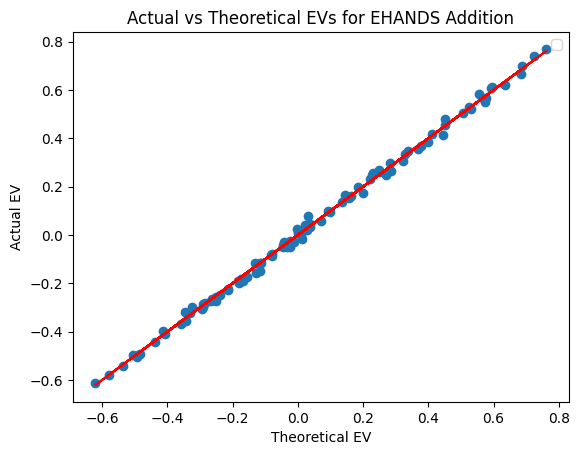

In [9]:
actual_evs = []
theoretical_evs = []

for _ in range(100):
    input_values = (random.uniform(-0.99, 0.99), random.uniform(-0.99, 0.99), random.choice([True, False]))
    #print(f"Testing with input values: {input_values}")
    ev_actual, ev_theory = test_ehands_addition(input_values[0], input_values[1], negation=input_values[2])
    actual_evs.append(ev_actual)
    theoretical_evs.append(ev_theory)

title = 'Actual vs Theoretical EVs for EHANDS Addition'
x_label = 'Theoretical EV'
y_label = 'Actual EV'
plot_residuals(actual_evs, theoretical_evs, title, x_label, y_label)


## Vertex Classification Setup with QCrank

In [10]:
def compute_qubit_counts(data):
    """
    Compute the number of address qubits and data qubits needed to encode a dataset.
    
    :param data: A list or array of data points to be encoded.
    
    :return: A tuple (address_qubits, data_qubits) where:
             - address_qubits is the number of qubits needed to encode the indices of the data points.
             - data_qubits is the number of qubits needed to encode each data point.
    """
    data = np.array(data)
    n_data = data.shape[0]

    # number of data qubits
    if data.ndim == 1:
        data_qubits = 1
    else:
        data_qubits = data.shape[1]

    # number of address qubits
    address_qubits = math.ceil(math.log2(n_data))

    return address_qubits, data_qubits

In [11]:
def encode_with_qcrank(data):
    """
    Adapted from Chris Pestano's QSobel ehands_encoding_to_qcrank().
    This function takes in a dataset and encodes it into quantum circuits using the ParametricQCrankV2 data encoding circuit.
    
    :param data: A 1D numpy array of shape (n_data,) representing the dataset to be encoded. Each element corresponds to a data point.

    :return: A dictionary containing the following keys:
                - 'data_circs': A list of QuantumCircuits, each encoding a data point from the dataset.
                - 'param_qcrankObj': The ParametricQCrankV2 object used for encoding, which contains information about the circuit structure and parameters.
                - 'nq_addr': The number of address qubits used for encoding the dataset.
                - 'nq_data': The number of data qubits used for encoding each data point.
                - 'addr_qubits': A list of indices corresponding to the address qubits in the circuits.
    """
    nq_addr, nq_data = compute_qubit_counts(data)

    #print("Number of address qubits needed:", nq_addr)
    #print("Number of data qubits needed:", nq_data)

    # reshape data to have shape (n_data, nq_data, 1) for compatibility with the data encoding circuit
    n_data = len(data)
    data = data.reshape(n_data, nq_data, 1)
    #print("Input data values:")
    #print(data) 

    # Adapted from Chris Pestano's QSobel
    # This function is from an outside directory provided by the AQuA-DATA team at LBNL (see data-encoder-circuits directory)
    param_qcrankObj = ParametricQCrankV2.ParametricQCrankV2( nq_addr, nq_data, useCZ=False, measure=False, barrier=True )
    # Important NOTE: QCrankV2 has address qubits on the LSQBs, V1 had an option to reverse bits during initialization, but that is not present in V2

    param_qcrankObj.bind_data(data)
    # generate the instantiated circuits
    # rotation gates values are mapped to their respective gates 
    data_circs = param_qcrankObj.instantiate_circuits()
    #print(f"Generated {len(data_circs)} data encoding circuits.")
    addr_qubits = list(range(nq_addr))

    return {
    'data_circs': data_circs,
    'param_qcrankObj': param_qcrankObj,
    'nq_addr': nq_addr,
    'nq_data': nq_data,
    'addr_qubits': addr_qubits
    }

In [12]:
def get_EV(counts, nq_addr, target_qubit=3):
    """
    Adapted from Chris Pestano's QSobel get_EV().
    Given the counts from a Qiskit simulator, compute the expectation value <Z> for a target data qubit, conditioned on the address qubits. This will give us the expectation value for each element in the dataset.
    
    counts: dict of counts from Qiskit simulator (basis state -> count)
    nq_addr: number of address qubits
    target_qubit: the data qubit to measure (as a string, e.g., '1')
    
    Returns:
        np.array of expectation values <Z> for each element
    """
    n_elements = 2**nq_addr
    expectations = np.zeros(n_elements, dtype=float)

    # iterate over each element in the dataset (each possible address)
    for i in range(n_elements):
        # Binary string for this address
        full_bit_0 = i                      # MSB, target data qubit = 0
        full_bit_1 = (1 << nq_addr) | i     # MSB, target data qubit = 1

        count_0 = counts.get(format(full_bit_0, f'0{nq_addr+1}b'), 0)
        count_1 = counts.get(format(full_bit_1, f'0{nq_addr+1}b'), 0)

        if (count_0 + count_1) > 0:
            ev = (count_0 - count_1) / (count_0 + count_1)
        else:
            ev = 0
            
        expectations[i] = ev

    return expectations

Slope of line of best fit: 0.4764


C:\Users\burne\AppData\Local\Temp\ipykernel_13228\3893791314.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


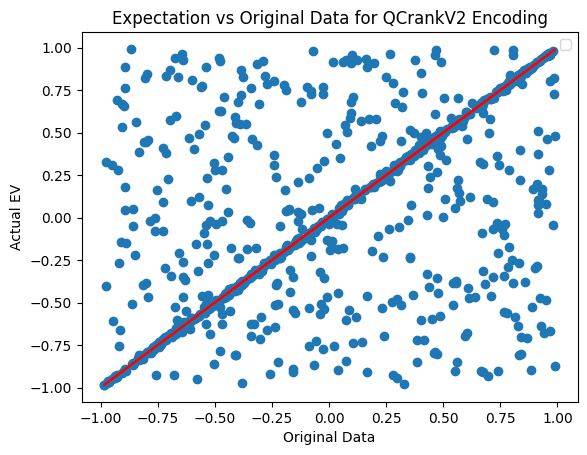

In [13]:
# Marching Cubes Vertex Classification
iso_value = 0.5

n_cubes = 1
n_data = n_cubes * 2**3

actual_evs_list = []
all_data_list = []

for trial in range(100):
    # generate random data between -0.99 and 0.99
    data = np.random.uniform(-0.99, 0.99, n_data)
    all_data_list.append(data)

    # encode with QCrankV2
    encoding_args = encode_with_qcrank(data)
    qc = encoding_args['data_circs'][0]
    nq_addr = encoding_args['nq_addr']
    nq_data = encoding_args['nq_data']
    data_qubit = nq_addr  # leftmost qubit

    # Statevector for theoretical EVs
    state = Statevector.from_instruction(qc)
    
    # Measure circuit and get counts
    qc.measure_all()
    counts = run_sim_job(qc, n_shots=n_data * (2**12))

    # Actual EVs from counts 
    actual_evs = get_EV(counts, nq_addr)
    actual_evs_list.append(actual_evs)

# Plot residuals
actual_flat = np.concatenate(actual_evs_list)
data_flat = np.concatenate(all_data_list)
title = "Expectation vs Original Data for QCrankV2 Encoding"
x_label = "Original Data"
y_label = "Actual EV"
plot_residuals(actual_flat, data_flat, title, x_label, y_label)


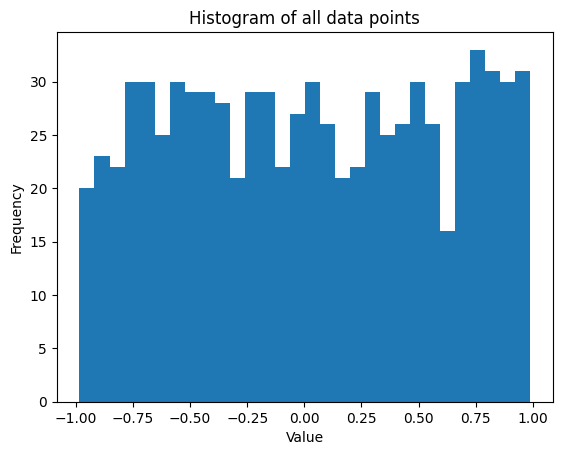

In [27]:
plt.hist(np.concatenate(all_data_list), bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of all data points")
plt.show()

Element | <Z> Expectation | Original Value
   0    |     0.4942      |     0.4730    
   1    |     0.7091      |     0.5020    
   2    |     0.3122      |     0.3089    
   3    |     0.7849      |    -0.5555    
   4    |     0.5100      |     0.7014    
   5    |     0.4864      |     0.4688    
   6    |     -0.5519     |     0.7796    
   7    |     -0.4548     |    -0.4482    


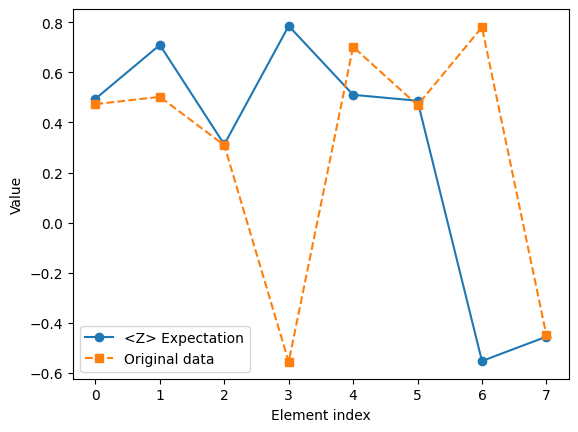

In [28]:
counts = run_sim_job(qc, n_shots=n_data * (2**12))

nq_addr = encoding_args['nq_addr']
expectations = get_EV(counts, nq_addr)
print("Element | <Z> Expectation | Original Value")
for i, z in enumerate(expectations):
    print(f"{i:^7} | {z:^15.4f} | {data[i]:^14.4f}")

plt.plot(range(len(data)), expectations, 'o-', label='<Z> Expectation')
plt.plot(range(len(data)), data, 's--', label='Original data')
plt.xlabel('Element index')
plt.ylabel('Value')
plt.legend()
plt.show()

## Notes 03/09/26

look into plotting statistical error for binomial distr, make a plot like Chris' (y=actual vs x=expected)

give plot titles

just use a few pre-selected weights, don't need to find the optimal weight

when doing the actual subtraction, try 2 different methods:

- method 1: encode isovalue into array of same length as data, then do elementwise subtraction

- method 2: encode isovalue into the weight of the EHands addition, then do subtraction that way (ask Dr. Bethel for more details)

    - let d[i] = data[i]
    - let t = isolevel
    - step 1: compute NEG(t)
    - step 2: compute weight sum of d[i] + NEG(t) using w = 0.5
    - step 3: multiply step 2 by 2.0

when running tests, the standard number of shots is 4k per data point 

there is some bug possibly in the calculation of EV in get_EV()

how long does circuit get for data size N? (compound metric (1 and multi qubit gates))